# Semana 2 — Dataset y DataLoaders
### Detector de Rostros de Futbolistas Argentinos · FIFA 2022

**Flujo del notebook:**
1. Obtener el dataset de rostros (desde Kaggle la primera vez, desde Drive las siguientes)
2. Extraer rostros con InsightFace *(solo primera vez — paralelizado con GPU automático)*
3. Filtrar jugadores argentinos y construir el DataFrame
4. Split estratificado 60 / 20 / 20 y guardar CSVs
5. Definir `FaceDataset` con **banderas individuales** de augmentation
6. Crear `DataLoader` de train, val y test con `build_dataloader`

In [1]:
# ============================================================
# INSTALACION DE DEPENDENCIAS (Apto para local y Google Colab)
# ============================================================
import sys
import subprocess

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # En Colab instalamos con subprocess para evitar problemas con comandos !
    print("Google Colab detectado. Instalando dependencias...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "insightface", "onnxruntime-gpu", "gdown",
                           "pandas", "scikit-learn", "tqdm"])
    print("✅  Dependencias instaladas.")
else:
    # Ejecucion local: forzamos onnxruntime-gpu para CUDA en Windows/Linux
    print("Entorno local detectado. Instalando y configurando dependencias...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "insightface", "gdown", "pandas", "scikit-learn", "tqdm"])
    subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y",
                     "onnxruntime", "onnxruntime-gpu"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--no-cache-dir", "onnxruntime-gpu"])
    print("\n[IMPORTANTE] Instalacion completada. Por favor REINICIA EL KERNEL antes de continuar.")


Entorno local detectado. Instalando y configurando dependencias...



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\light\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Found existing installation: onnxruntime 1.23.2
Uninstalling onnxruntime-1.23.2:
  Successfully uninstalled onnxruntime-1.23.2
Found existing installation: onnxruntime-gpu 1.23.2
Uninstalling onnxruntime-gpu-1.23.2:
  Successfully uninstalled onnxruntime-gpu-1.23.2

[IMPORTANTE] Instalacion completada. Por favor REINICIA EL KERNEL de Jupyter antes de continuar.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\light\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import random
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [3]:
# ================================================================
# CONFIGURACION GLOBAL — Ajustar aqui antes de ejecutar
# ================================================================
import sys, os
from pathlib import Path

# Detectar entorno (ya debería estar definido desde cell-install, pero lo
# redefinimos aquí para seguridad en caso de ejecutar sólo esta celda)
IN_COLAB = 'google.colab' in sys.modules

# --- Control de flujo ---
# En Colab: usar True para descargar el ZIP de caras ya procesadas desde Drive.
# En local:  False solo en la primera corrida (extrae caras con InsightFace).
SKIP_EXTRACTION  = True       # ← En Colab SIEMPRE usar True
DRIVE_ZIP_ID     = "1bf4dkkJWgH02et9NfVVxJis1X4C9nLsu"  # ZIP de caras en Drive

# --- Extraccion de rostros (solo si SKIP_EXTRACTION = False) ---
USE_PADDING      = False      # Agregar margen alrededor del rostro
PADDING_PX       = 15        # Tamano del margen en pixeles
IMG_SIZE         = 224       # Tamano de salida (224x224)
MAX_WORKERS      = 4         # Workers paralelos para extraccion (CPU)

# --- Augmentaciones de entrenamiento ---
USE_FLIP         = True      # RandomHorizontalFlip(p=0.5)
USE_COLOR_JITTER = True      # ColorJitter: brillo, contraste, saturacion

# --- DataLoader ---
BATCH_SIZE       = 32
NUM_WORKERS      = 0

# --- Rutas (automáticas según entorno) ---
if IN_COLAB:
    # En Colab usamos /content/data como base
    DATA_DIR    = "/content/data"
    DATASET_DIR = "/content/data/FIFA_2022_ALL_PLAYERS"
    FACES_DIR   = "/content/data/FIFA_2022_ONLY_FACES"
else:
    # En local el notebook está en dev/ → ../data apunta a la carpeta raíz data/
    DATA_DIR    = "../data"
    DATASET_DIR = "../data/FIFA_2022_ALL_PLAYERS"
    FACES_DIR   = "../data/FIFA_2022_ONLY_FACES"

os.makedirs(DATA_DIR, exist_ok=True)

print(f"Entorno  : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"DATA_DIR : {DATA_DIR}")
print(f"FACES_DIR: {FACES_DIR}")
print(f"Configuracion activa:")
print(f"  SKIP_EXTRACTION  = {SKIP_EXTRACTION}")
print(f"  USE_PADDING      = {USE_PADDING}  (px={PADDING_PX})")
print(f"  USE_FLIP         = {USE_FLIP}")
print(f"  USE_COLOR_JITTER = {USE_COLOR_JITTER}")
print(f"  BATCH_SIZE       = {BATCH_SIZE}")


Configuracion activa:
  SKIP_EXTRACTION  = False
  USE_PADDING      = False  (px=15)
  USE_FLIP         = True
  USE_COLOR_JITTER = True
  BATCH_SIZE       = 32


## Paso 1: Obtener el dataset de rostros

| `SKIP_EXTRACTION` | Accion |
|---|---|
| `False` *(primera vez)* | Descarga el dataset original de Kaggle (~360 MB) |
| `True` *(corridas siguientes)* | Descarga el ZIP de rostros ya procesados desde Drive |

> **Primera vez:** agregar el token de Kaggle en **Secretos de Colab** con el nombre `KAGGLE_TOKEN`.

In [4]:
# ================================================================
# CONFIGURACION GLOBAL — Ajustar aqui antes de ejecutar
# ================================================================
import sys, os
from pathlib import Path

# Detectar entorno (ya debería estar definido desde cell-install, pero lo
# redefinimos aquí para seguridad en caso de ejecutar sólo esta celda)
IN_COLAB = 'google.colab' in sys.modules

# --- Control de flujo ---
# En Colab: usar True para descargar el ZIP de caras ya procesadas desde Drive.
# En local:  False solo en la primera corrida (extrae caras con InsightFace).
SKIP_EXTRACTION  = True       # ← En Colab SIEMPRE usar True
DRIVE_ZIP_ID     = "1bf4dkkJWgH02et9NfVVxJis1X4C9nLsu"  # ZIP de caras en Drive

# --- Extraccion de rostros (solo si SKIP_EXTRACTION = False) ---
USE_PADDING      = False      # Agregar margen alrededor del rostro
PADDING_PX       = 15        # Tamano del margen en pixeles
IMG_SIZE         = 224       # Tamano de salida (224x224)
MAX_WORKERS      = 4         # Workers paralelos para extraccion (CPU)

# --- Augmentaciones de entrenamiento ---
USE_FLIP         = True      # RandomHorizontalFlip(p=0.5)
USE_COLOR_JITTER = True      # ColorJitter: brillo, contraste, saturacion

# --- DataLoader ---
BATCH_SIZE       = 32
NUM_WORKERS      = 0

# --- Rutas (automáticas según entorno) ---
if IN_COLAB:
    # En Colab usamos /content/data como base
    DATA_DIR    = "/content/data"
    DATASET_DIR = "/content/data/FIFA_2022_ALL_PLAYERS"
    FACES_DIR   = "/content/data/FIFA_2022_ONLY_FACES"
else:
    # En local el notebook está en dev/ → ../data apunta a la carpeta raíz data/
    DATA_DIR    = "../data"
    DATASET_DIR = "../data/FIFA_2022_ALL_PLAYERS"
    FACES_DIR   = "../data/FIFA_2022_ONLY_FACES"

os.makedirs(DATA_DIR, exist_ok=True)

print(f"Entorno  : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"DATA_DIR : {DATA_DIR}")
print(f"FACES_DIR: {FACES_DIR}")
print(f"Configuracion activa:")
print(f"  SKIP_EXTRACTION  = {SKIP_EXTRACTION}")
print(f"  USE_PADDING      = {USE_PADDING}  (px={PADDING_PX})")
print(f"  USE_FLIP         = {USE_FLIP}")
print(f"  USE_COLOR_JITTER = {USE_COLOR_JITTER}")
print(f"  BATCH_SIZE       = {BATCH_SIZE}")


Descargando dataset con kagglehub...


100%|██████████| 361M/361M [00:29<00:00, 12.9MB/s] 

Extracting files...


Moviendo los archivos descargados a ../data/FIFA_2022_ALL_PLAYERS...
Cache temporal de descarga limpiado correctamente.
Dataset original disponible en: ../data/FIFA_2022_ALL_PLAYERS


## Paso 2: Extraccion de rostros con InsightFace *(solo primera vez)*

- Detecta el rostro **mas grande** en cada imagen.
- Aplica el margen configurado con `USE_PADDING` / `PADDING_PX`.
- Usa **GPU automaticamente** si esta disponible; cae en CPU si no.
- Procesamiento **paralelo** con `ThreadPoolExecutor` — barra de progreso con `tqdm`.
- Al terminar, comprime el resultado y lo guarda en Google Drive.

In [5]:
if not SKIP_EXTRACTION:
    import torch
    import onnxruntime as ort
    from insightface.app import FaceAnalysis
    import numpy as np
    import cv2
    from pathlib import Path
    from concurrent.futures import ThreadPoolExecutor
    from tqdm import tqdm
    from concurrent.futures import as_completed
    
    # Deteccion automatica GPU / CPU
    available = ort.get_available_providers()
    providers = (
        ["CUDAExecutionProvider", "CPUExecutionProvider"]
        if "CUDAExecutionProvider" in available
        else ["CPUExecutionProvider"]
    )
    print(f"Provider: {providers[0]}")
    
    app = FaceAnalysis(providers=providers)
    app.prepare(ctx_id=0, det_size=(640, 640))
    
    def extract_face(img, use_padding=USE_PADDING, padding_px=PADDING_PX):
        """Recorta el rostro del jugador, descartando fotos grupales ambiguas."""
        faces = app.get(img)
        if not faces:
            return None
            
        # Calcular areas de los rostros detectados
        faces_with_areas = []
        for face in faces:
            w_f = face.bbox[2] - face.bbox[0]
            h_f = face.bbox[3] - face.bbox[1]
            faces_with_areas.append((face, w_f * h_f))
            
        # Ordenar por area de mayor a menor
        faces_with_areas.sort(key=lambda x: x[1], reverse=True)
        
        # Heuristica de descarte: si hay mas de un rostro y el segundo es de tamaño comparable,
        # descartamos la imagen por ambigüedad (evita entrenar con fotos grupales/otros jugadores).
        if len(faces_with_areas) > 1:
            largest_face, largest_area = faces_with_areas[0]
            second_face, second_area = faces_with_areas[1]
            if largest_area < 2.5 * second_area:
                return None  # Descartar por ambigüedad grupal
                
        # Si paso el filtro, usamos el rostro mas grande
        face = faces_with_areas[0][0]
        x1, y1, x2, y2 = map(int, face.bbox)
        h, w = img.shape[:2]
        if use_padding:
            x1 = max(0, x1 - padding_px)
            y1 = max(0, y1 - padding_px)
            x2 = min(w, x2 + padding_px)
            y2 = min(h, y2 + padding_px)
        crop = img[y1:y2, x1:x2]
        return cv2.resize(crop, (IMG_SIZE, IMG_SIZE)) if crop.size > 0 else None
        
    def fix_encoding(name):
        try:
            return name.encode("cp866").decode("utf-8")
        except Exception:
            try:
                return name.encode("cp437").decode("utf-8")
            except Exception:
                try:
                    return name.encode("latin1").decode("utf-8")
                except Exception:
                    return name
                    
    dataset_root = Path(DATASET_DIR)
    output_root  = Path(FACES_DIR)
    output_root.mkdir(parents=True, exist_ok=True)
    extensions   = {".jpg", ".jpeg", ".png"}
    
    # Filtramos para procesar unicamente las imagenes de Argentina (ahorra mucho tiempo y disco)
    img_files    = [p for p in dataset_root.rglob("*") if p.suffix.lower() in extensions and any("argentina" in part.lower() for part in p.parts)]
    
    saved_count = 0
    
    def process_file(img_file):
        import numpy as np
        try:
            # Leer archivo usando numpy para soportar caracteres unicode en Windows
            img_data = np.fromfile(str(img_file), dtype=np.uint8)
            img = cv2.imdecode(img_data, cv2.IMREAD_COLOR)
        except Exception:
            img = None
            
        if img is None:
            return False
        face = extract_face(img)
        if face is None:
            return False
            
        # Corregir la codificación de las partes de la ruta para guardar limpio en el disco
        rel_path = img_file.relative_to(dataset_root)
        clean_parts = [fix_encoding(part) for part in rel_path.parts]
        save_path = output_root / Path(*clean_parts)
        
        save_path.parent.mkdir(parents=True, exist_ok=True)
        try:
            # Escribir archivo usando numpy para soportar caracteres unicode en Windows
            ext = save_path.suffix
            is_success, im_buf_arr = cv2.imencode(ext, face)
            if is_success:
                im_buf_arr.tofile(str(save_path))
                return True
        except Exception:
            pass
        return False
        
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(process_file, f): f for f in img_files}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Extrayendo rostros"):
            if fut.result():
                saved_count += 1
                
    print(f"Procesadas: {len(img_files)}  |  Rostros guardados: {saved_count}")

Provider: CUDAExecutionProvider
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\light/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionP

Extrayendo rostros:   0%|          | 0/1300 [00:00<?, ?it/s]

Procesadas: 1300  |  Rostros guardados: 1269


In [6]:
if not SKIP_EXTRACTION:
    # Esta sección originalmente estaba pensada para Colab, donde se guardaba el ZIP a Drive.
    # Como ahora estás trabajando localmente, guardamos el ZIP en la misma carpeta data/
    
    zip_output_path = f"{DATA_DIR}/FIFA_2022_ONLY_FACES.zip"
    
    import zipfile
    with zipfile.ZipFile(zip_output_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        faces_path = Path(FACES_DIR)
        for root, dirs, files in os.walk(faces_path):
            for file in files:
                file_path = os.path.join(root, file)
                # Guardar con ruta relativa dentro del zip
                arcname = os.path.relpath(file_path, faces_path.parent)
                zipf.write(file_path, arcname)

    print(f"ZIP de rostros guardado localmente en: {zip_output_path}")

ZIP de rostros guardado localmente en: ../data/FIFA_2022_ONLY_FACES.zip


## Paso 3: DataFrame de Argentina

Se filtran solo los jugadores de la seleccion argentina y se construye el mapeo `label -> indice` necesario para el entrenamiento.

In [7]:
def fix_encoding(name):
    try:
        # Intenta primero corregir el encoding CP866 común en consolas Windows de ciertas regiones
        return name.encode("cp866").decode("utf-8")
    except Exception:
        try:
            # Intenta luego corregir el encoding CP437 típico de descompresión en Windows
            return name.encode("cp437").decode("utf-8")
        except Exception:
            try:
                # Fallback para Latin1 (común en Linux/Mac)
                return name.encode("latin1").decode("utf-8")
            except Exception:
                return name

faces_root = Path(FACES_DIR)
print(f"Buscando imagenes en: {faces_root}")
print(f"Ruta existe: {faces_root.exists()}")

extensions = {".jpg", ".jpeg", ".png"}

records = []
for img_path in faces_root.rglob("*"):
    if img_path.suffix.lower() not in extensions:
        continue
    
    # Obtenemos la ruta relativa para buscar en las partes
    rel_path = img_path.relative_to(faces_root)
    parts = rel_path.parts
    
    if len(parts) < 2:
        continue
        
    # Verificamos si alguna parte del directorio dice "argentina"
    is_argentina = any("argentina" in p.lower() for p in parts)
    
    if not is_argentina:
        continue
        
    # La carpeta del jugador es el penúltimo directorio en la ruta
    # porque asume que es .../Argentina Players/Images_Jugador/imagen.jpg
    player_dir_name = parts[-2]
    
    # Limpiamos si tiene un prefijo como 'Images_'
    player_name = player_dir_name.replace("Images_", "")
    
    records.append({
        "image_path": str(rel_path),
        "label":      fix_encoding(player_name),
    })

print(f"Imagenes encontradas: {len(records)}")

if len(records) == 0:
    print("ADVERTENCIA: No se encontraron imagenes de Argentina.")
    print("Asegurate de que FACES_DIR apunta al directorio correcto.")
    df = pd.DataFrame({"image_path": [], "label": [], "label_idx": []})
else:
    df = pd.DataFrame(records)
    
    # Eliminar jugadores con menos de 5 imagenes
    counts = df["label"].value_counts()
    df = df[df["label"].isin(counts[counts >= 5].index)].reset_index(drop=True)
    
    # Mapeo label <-> indice
    all_labels   = sorted(df["label"].unique())
    label_to_idx = {lbl: i for i, lbl in enumerate(all_labels)}
    idx_to_label = {i: lbl for lbl, i in label_to_idx.items()}
    df["label_idx"] = df["label"].map(label_to_idx)
    
    print(f"Jugadores: {df['label'].nunique()}  |  Imagenes: {len(df)}")
    print(df["label"].value_counts().to_string())


Buscando imagenes en: ..\data\FIFA_2022_ONLY_FACES
Ruta existe: True
Imagenes encontradas: 1269
Jugadores: 26  |  Imagenes: 1269
label
Alexis Mac Allister       50
Cristian Romero           50
Guido Rodríguez           50
Marcos Acuña              50
Lautaro Martínez          50
Julián Álvarez            50
Nahuel Molina             50
Emiliano Martínez         49
Gerónimo Rulli            49
Enzo Fernández            49
Thiago Almada             49
Nicolás Tagliafico        49
Paulo Dybala              49
Gonzalo Montiel           49
Leandro Paredes           49
Juan Foyth                49
Lisandro Martínez         49
Nicolás Otamendi          49
Rodrigo De Paul           49
Papu Gómez                48
Exequiel Palacios         48
Franco Armani             48
Germán Pezzella           47
Ángel Correa              47
Ángel Di María            47
Lionel Messi (captain)    46


## Paso 4: Split 60 / 20 / 20 y guardado

Split estratificado por jugador. Se guardan en `DATA_DIR`:
- `train.csv`, `val.csv`, `test.csv`
- `label_to_idx.json` — necesario en produccion para decodificar la prediccion del modelo

In [8]:
train_df, temp_df = train_test_split(
    df, test_size=0.40, stratify=df["label_idx"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_idx"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

train_df.to_csv(f"{DATA_DIR}/train.csv", index=False)
val_df.to_csv(  f"{DATA_DIR}/val.csv",   index=False)
test_df.to_csv( f"{DATA_DIR}/test.csv",  index=False)

with open(f"{DATA_DIR}/label_to_idx.json", "w", encoding="utf-8") as f:
    json.dump(label_to_idx, f, ensure_ascii=False, indent=2)

total = len(train_df) + len(val_df) + len(test_df)
print(f"TRAIN : {len(train_df):4d} imagenes  ({len(train_df)/total*100:.1f}%)")
print(f"VAL   : {len(val_df):4d} imagenes  ({len(val_df)/total*100:.1f}%)")
print(f"TEST  : {len(test_df):4d} imagenes  ({len(test_df)/total*100:.1f}%)")
print(f"TOTAL : {total}")
print(f"Archivos guardados en {DATA_DIR}/")

TRAIN :  761 imagenes  (60.0%)
VAL   :  254 imagenes  (20.0%)
TEST  :  254 imagenes  (20.0%)
TOTAL : 1269
Archivos guardados en ../data/


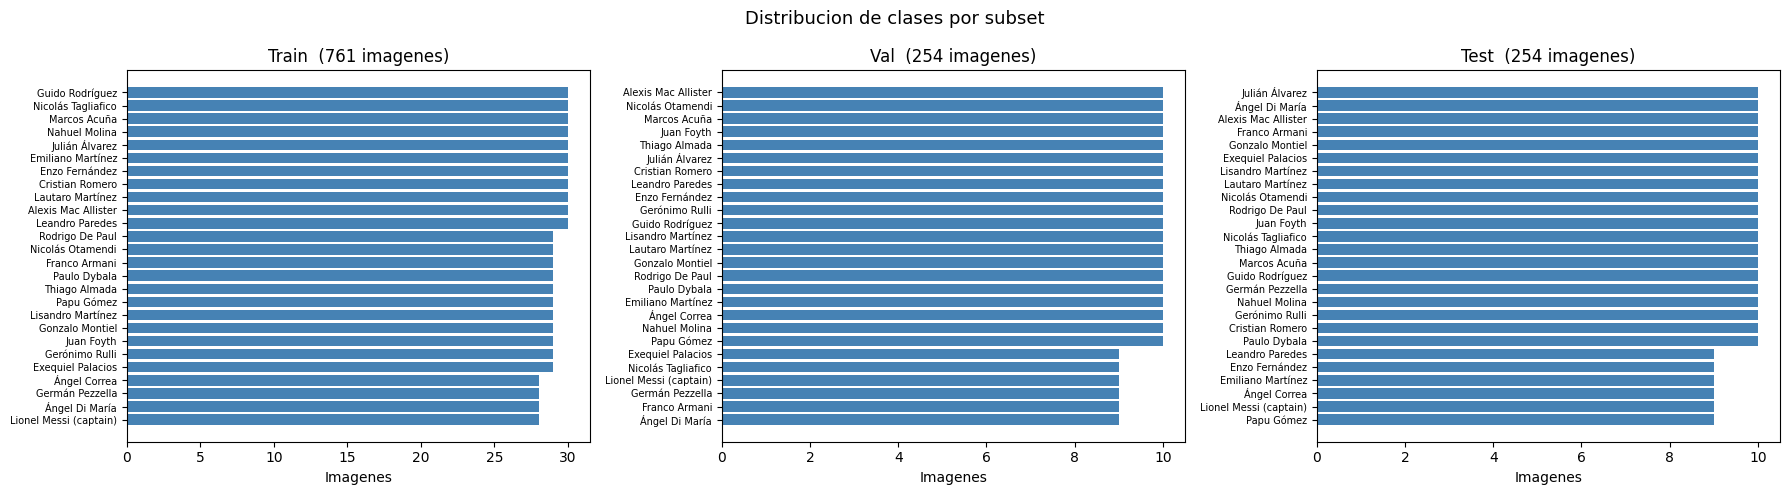

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = [(train_df, "Train"), (val_df, "Val"), (test_df, "Test")]

for ax, (split_df, name) in zip(axes, splits):
    cnt = split_df["label"].value_counts().sort_values()
    ax.barh(cnt.index, cnt.values, color="steelblue")
    ax.set_title(f"{name}  ({len(split_df)} imagenes)")
    ax.set_xlabel("Imagenes")
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Distribucion de clases por subset", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\light\AppData\Local\Temp\ipykernel_5056\2164541024.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(1, random_state=42))


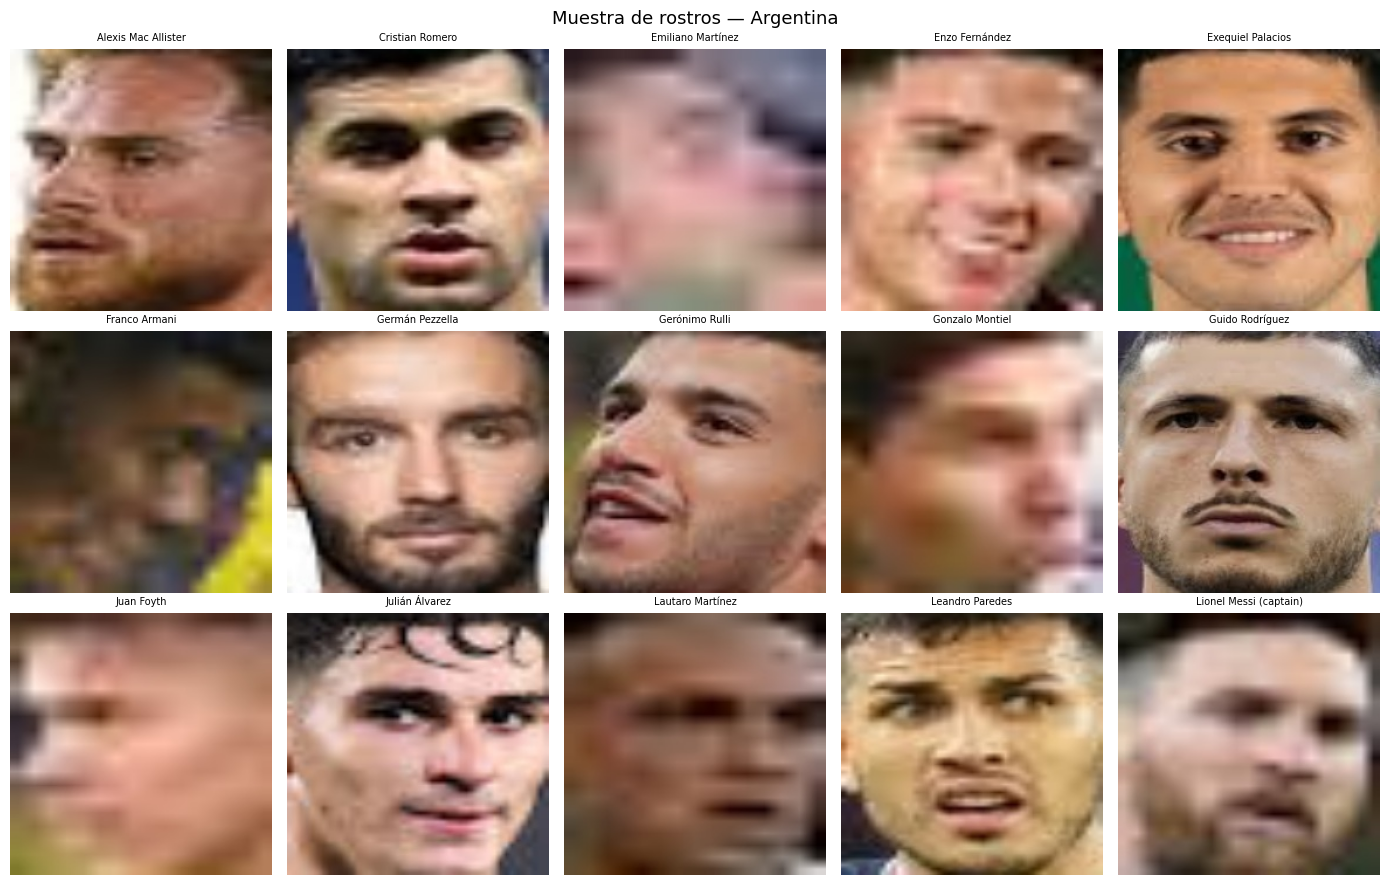

In [10]:
# Muestra un ejemplo por jugador (primeros 15)
sample_per_player = (
    df.groupby("label", group_keys=False)
      .apply(lambda g: g.sample(1, random_state=42))
      .reset_index(drop=True)
    .head(15)
)

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
for ax, (_, row) in zip(axes.flatten(), sample_per_player.iterrows()):
    # Usamos PIL en lugar de cv2.imread porque cv2 falla en Windows con rutas que tienen caracteres Unicode/tildes
    img = Image.open(faces_root / row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.set_title(row["label"], fontsize=7)
    ax.axis("off")

plt.suptitle("Muestra de rostros — Argentina", fontsize=13)
plt.tight_layout()
plt.show()

## Paso 5: Dataset y DataLoaders

`FaceDataset` recibe **una bandera por augmentation** para activarlas independientemente.
`build_dataloader` es el unico punto de entrada para construir cualquier loader.

| Bandera | Transformacion aplicada |
|---|---|
| `use_flip=True` | `RandomHorizontalFlip(p=0.5)` |
| `use_color_jitter=True` | `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)` |

Sin banderas: solo `Resize → ToTensor → Normalize` (usado en val y test).

In [11]:
class FaceDataset(Dataset):

    def __init__(self, dataframe, root_dir, use_flip=False, use_color_jitter=False):
        self.df       = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)

        steps = [transforms.Resize((224, 224))]

        if use_flip:
            steps.append(transforms.RandomHorizontalFlip(p=0.5))
        if use_color_jitter:
            steps.append(transforms.ColorJitter(
                brightness=0.2, contrast=0.2, saturation=0.2
            ))

        steps += [
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ]
        self.transform = transforms.Compose(steps)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row["image_path"]).convert("RGB")
        return self.transform(img), int(row["label_idx"])

In [12]:
def build_dataloader(df, root_dir,
                     use_flip=False, use_color_jitter=False,
                     shuffle=False,
                     batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    dataset = FaceDataset(df, root_dir,
                          use_flip=use_flip,
                          use_color_jitter=use_color_jitter)
    return DataLoader(dataset,
                      batch_size=batch_size,
                      shuffle=shuffle,
                      num_workers=num_workers,
                      pin_memory=True)

In [13]:
train_loader = build_dataloader(
    train_df, FACES_DIR,
    use_flip=USE_FLIP,
    use_color_jitter=USE_COLOR_JITTER,
    shuffle=True
)
val_loader  = build_dataloader(val_df,  FACES_DIR, shuffle=False)
test_loader = build_dataloader(test_df, FACES_DIR, shuffle=False)

print(f"train_loader : {len(train_loader.dataset):4d} imagenes  {len(train_loader):3d} batches")
print(f"val_loader   : {len(val_loader.dataset):4d} imagenes  {len(val_loader):3d} batches")
print(f"test_loader  : {len(test_loader.dataset):4d} imagenes  {len(test_loader):3d} batches")

train_loader :  761 imagenes   24 batches
val_loader   :  254 imagenes    8 batches
test_loader  :  254 imagenes    8 batches


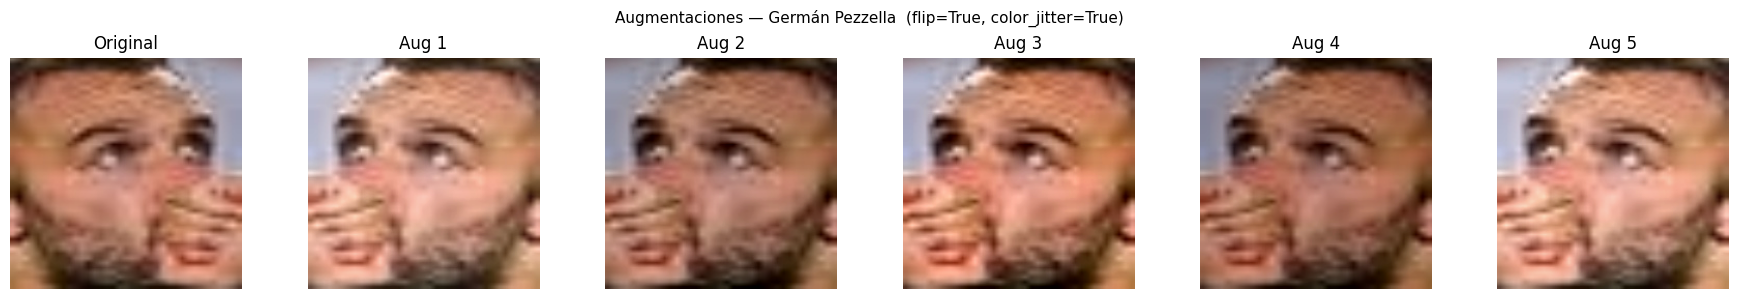

In [14]:
# 6 versiones aumentadas del mismo sample
sample_row  = train_df.iloc[0]
sample_img  = Image.open(faces_root / sample_row["image_path"]).convert("RGB")
player_name = sample_row["label"]

aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(sample_img.resize((224, 224)))
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    axes[i].imshow(aug_transform(sample_img))
    axes[i].set_title(f"Aug {i}")
    axes[i].axis("off")

flags_str = f"flip={USE_FLIP}, color_jitter={USE_COLOR_JITTER}"
plt.suptitle(f"Augmentaciones — {player_name}  ({flags_str})", fontsize=11)
plt.tight_layout()
plt.show()

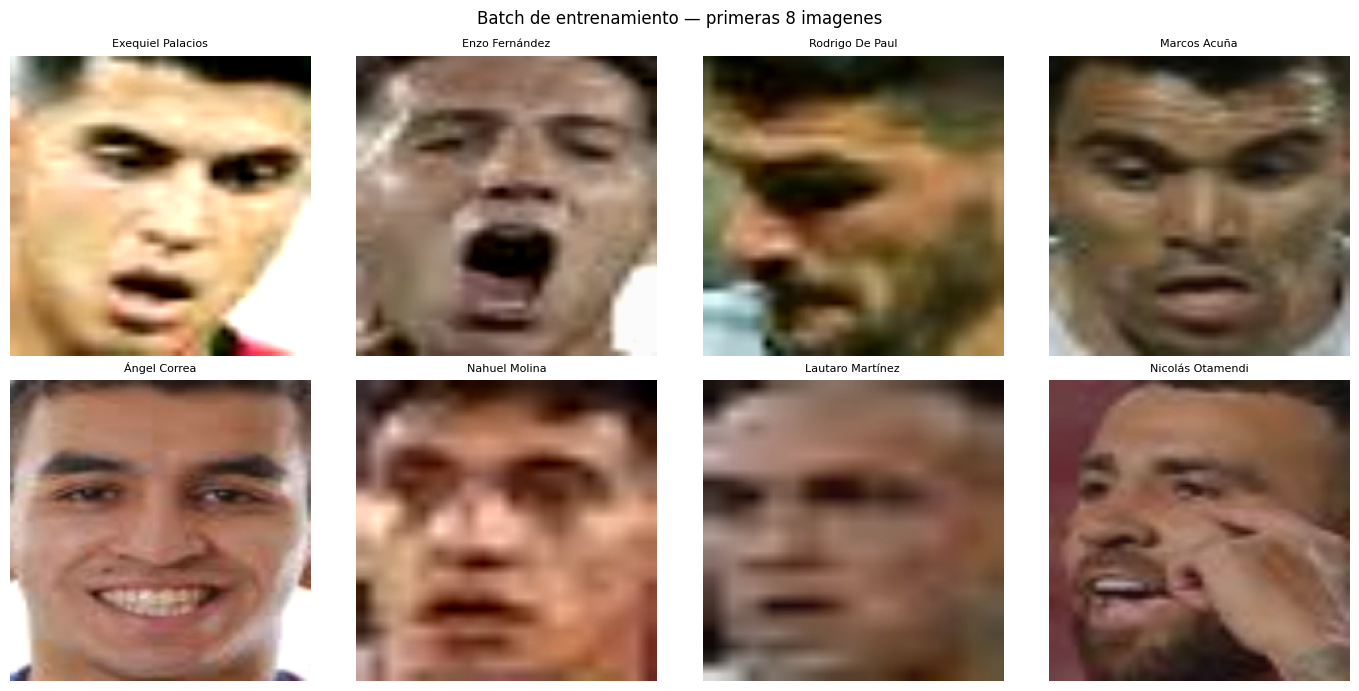

In [15]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, lbl in zip(axes.flatten(), images[:8], labels[:8]):
    ax.imshow(denormalize(img))
    ax.set_title(idx_to_label[lbl.item()], fontsize=8)
    ax.axis("off")

plt.suptitle("Batch de entrenamiento — primeras 8 imagenes", fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
images, labels = next(iter(train_loader))
total_split = len(train_loader.dataset) + len(val_loader.dataset) + len(test_loader.dataset)

print("=== Verificacion ===")
print(f"Shape del batch   : {images.shape}")
print(f"Dtype             : {images.dtype}")
print(f"Clases            : {len(label_to_idx)}")
print(f"Total en splits   : {total_split}  (esperado: {len(df)})")

assert images.shape == torch.Size([BATCH_SIZE, 3, 224, 224]), "Shape inesperado"
assert total_split == len(df), "El split no suma el total de imagenes"
print("OK — todo consistente")

=== Verificacion ===
Shape del batch   : torch.Size([32, 3, 224, 224])
Dtype             : torch.float32
Clases            : 26
Total en splits   : 1269  (esperado: 1269)
OK — todo consistente


In [17]:
# Descargar los archivos para commitear al repo
#from google.colab import files
#for fname in ["train.csv", "val.csv", "test.csv", "label_to_idx.json"]:
#    files.download(f"{DATA_DIR}/{fname}")